## Scenario - 1

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt 
import numpy as np  
import seaborn as sns

In [ ]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score

In [ ]:
df=pd.read_csv('Mall_Customers.csv')

In [ ]:
df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [ ]:
df.shape

(200, 5)

In [ ]:
df.isnull().sum()

CustomerID                0
Gender                    0
Age                       0
Annual Income (k$)        0
Spending Score (1-100)    0
dtype: int64

In [ ]:
X = df[['Annual Income (k$)', 'Spending Score (1-100)']]

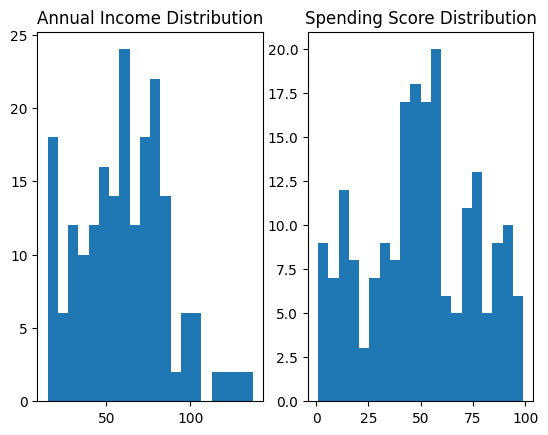

In [ ]:
plt.figure()

# Annual Income
plt.subplot(1, 2, 1)
plt.hist(X['Annual Income (k$)'], bins=20)
plt.title("Annual Income Distribution")
# Spending Score
plt.subplot(1, 2, 2)
plt.hist(X['Spending Score (1-100)'], bins=20)
plt.title("Spending Score Distribution")

plt.show()

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [ ]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

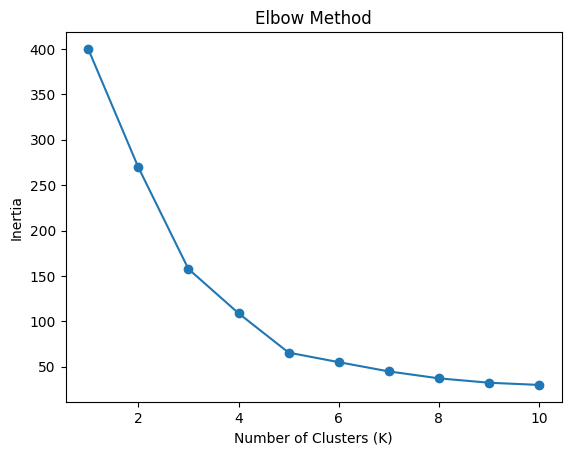

In [ ]:
plt.figure()
plt.plot(range(1, 11), inertia, marker='o')
plt.title("Elbow Method")
plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.show()

In [ ]:
k_optimal = 5
kmeans = KMeans(n_clusters=k_optimal, random_state=42, n_init=10)
clusters = kmeans.fit_predict(X_scaled)

In [ ]:
df['Cluster'] = clusters

print(df.head(10))

   CustomerID  Gender  Age  Annual Income (k$)  Spending Score (1-100)  \
0           1    Male   19                  15                      39   
1           2    Male   21                  15                      81   
2           3  Female   20                  16                       6   
3           4  Female   23                  16                      77   
4           5  Female   31                  17                      40   
5           6  Female   22                  17                      76   
6           7  Female   35                  18                       6   
7           8  Female   23                  18                      94   
8           9    Male   64                  19                       3   
9          10  Female   30                  19                      72   

   Cluster  
0        4  
1        2  
2        4  
3        2  
4        4  
5        2  
6        4  
7        2  
8        4  
9        2  


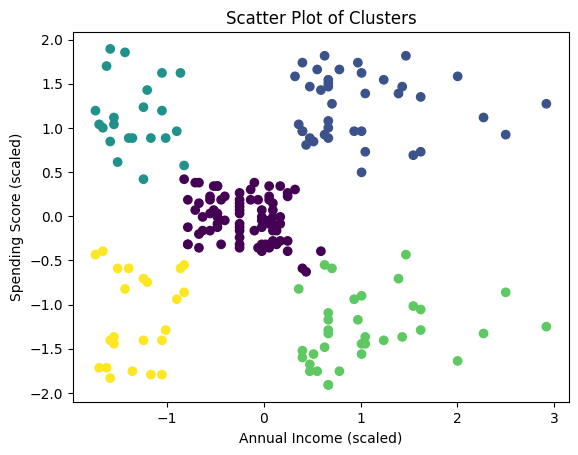

In [ ]:
plt.figure()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=clusters)

plt.title("Scatter Plot of Clusters")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")

plt.show()

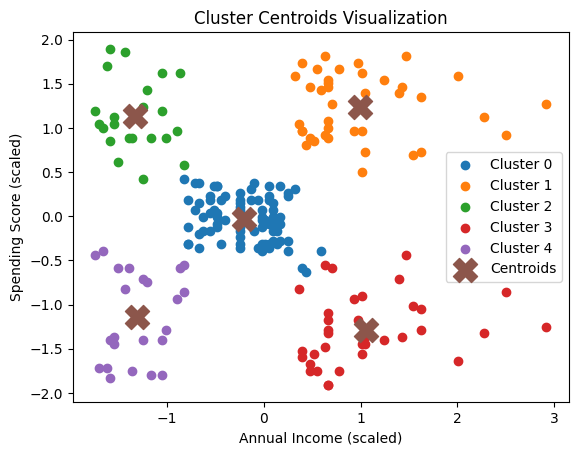

In [ ]:
plt.figure()

# Plot each cluster separately (for better clarity)
for i in range(k_optimal):
    plt.scatter(X_scaled[clusters == i, 0],
                X_scaled[clusters == i, 1],
                label=f'Cluster {i}')

# Plot centroids
plt.scatter(kmeans.cluster_centers_[:, 0],
            kmeans.cluster_centers_[:, 1],
            marker='X', s=300, label='Centroids')

# Labels
plt.title("Cluster Centroids Visualization")
plt.xlabel("Annual Income (scaled)")
plt.ylabel("Spending Score (scaled)")
plt.legend()

plt.show()

In [ ]:

# 9. Interpretation (Cluster Means)
print("\nCluster Summary:")
print(df.groupby('Cluster')[['Annual Income (k$)', 'Spending Score (1-100)']].mean())

# Evaluation Metrics
print("\nInertia:", kmeans.inertia_)
print("Silhouette Score:", silhouette_score(X_scaled, clusters))


Cluster Summary:
         Annual Income (k$)  Spending Score (1-100)
Cluster                                            
0                 55.296296               49.518519
1                 86.538462               82.128205
2                 25.727273               79.363636
3                 88.200000               17.114286
4                 26.304348               20.913043

Inertia: 65.56840815571681
Silhouette Score: 0.5546571631111091


## Scenario - 2

In [ ]:
from sklearn.mixture import GaussianMixture

In [ ]:
gmm = GaussianMixture(n_components=5, random_state=42)
gmm.fit(X_scaled)

,"n_components n_components: int, default=1The number of mixture components.",5
,"covariance_type covariance_type: {'full', 'tied', 'diag', 'spherical'}, default='full'String describing the type of covariance parameters to use.Must be one of:- 'full': each component has its own general covariance matrix.- 'tied': all components share the same general covariance matrix.- 'diag': each component has its own diagonal covariance matrix.- 'spherical': each component has its own single variance.For an example of using `covariance_type`, refer to:ref:`sphx_glr_auto_examples_mixture_plot_gmm_selection.py`.",'full'
,"tol tol: float, default=1e-3The convergence threshold. EM iterations will stop when thelower bound average gain is below this threshold.",0.001
,"reg_covar reg_covar: float, default=1e-6Non-negative regularization added to the diagonal of covariance.Allows to assure that the covariance matrices are all positive.",1e-06
,"max_iter max_iter: int, default=100The number of EM iterations to perform.",100
,"n_init n_init: int, default=1The number of initializations to perform. The best results are kept.",1
,"init_params init_params: {'kmeans', 'k-means++', 'random', 'random_from_data'}, default='kmeans'The method used to initialize the weights, the means and theprecisions.String must be one of:- 'kmeans' : responsibilities are initialized using kmeans.- 'k-means++' : use the k-means++ method to initialize.- 'random' : responsibilities are initialized randomly.- 'random_from_data' : initial means are randomly selected data points... versionchanged:: v1.1 `init_params` now accepts 'random_from_data' and 'k-means++' as initialization methods.",'kmeans'
,"weights_init weights_init: array-like of shape (n_components, ), default=NoneThe user-provided initial weights.If it is None, weights are initialized using the `init_params` method.",None
,"means_init means_init: array-like of shape (n_components, n_features), default=NoneThe user-provided initial means,If it is None, means are initialized using the `init_params` method.",None
,"precisions_init precisions_init: array-like, default=NoneThe user-provided initial precisions (inverse of the covariancematrices).If it is None, precisions are initialized using the 'init_params'method.The shape depends on 'covariance_type':: (n_components,) if 'spherical', (n_features, n_features) if 'tied', (n_components, n_features) if 'diag', (n_components, n_features, n_features) if 'full'",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the random seed given to the method chosen to initialize theparameters (see `init_params`).In addition, it controls the generation of random samples from thefitted distribution (see the method `sample`).Pass an int for reproducible output across multiple function calls.See :term:`Glossary `.",42


In [ ]:
probabilities = gmm.predict_proba(X_scaled)

print("Sample Probabilities:\n", probabilities[:5])

Sample Probabilities:
 [[1.57689698e-05 1.88009163e-08 9.52031247e-04 5.20013085e-08
  9.99032129e-01]
 [1.62776204e-05 1.89596786e-04 9.99790184e-01 4.21013390e-23
  3.94154449e-06]
 [2.21339374e-19 9.52615737e-19 1.22549539e-12 1.86223280e-04
  9.99813777e-01]
 [1.05444778e-04 1.80087695e-04 9.99693745e-01 3.79390067e-21
  2.07229768e-05]
 [6.47301428e-05 3.84273231e-08 1.55669540e-03 4.75722704e-08
  9.98378488e-01]]


In [ ]:
gmm_labels = gmm.predict(X_scaled)

# Add to dataset
df['GMM_Cluster'] = gmm_labels

In [ ]:
# Log-Likelihood
print("Log-Likelihood:", gmm.score(X_scaled))

# AIC & BIC
print("AIC:", gmm.aic(X_scaled))
print("BIC:", gmm.bic(X_scaled))

# Silhouette Score
from sklearn.metrics import silhouette_score
print("Silhouette Score (GMM):", silhouette_score(X_scaled, gmm_labels))

Log-Likelihood: -2.262502621973241
AIC: 963.0010487892964
BIC: 1058.6522524191894
Silhouette Score (GMM): 0.5536892843811245


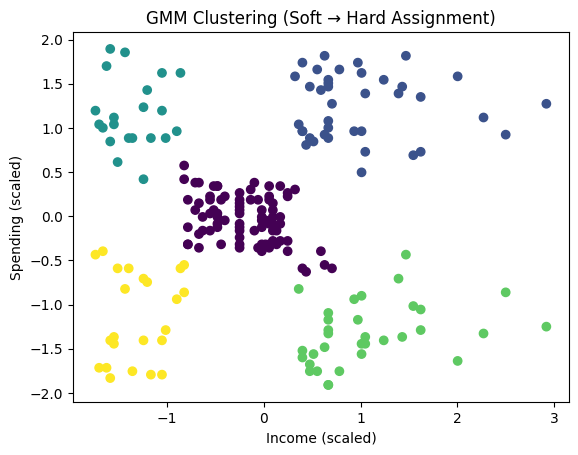

In [ ]:
plt.figure()

plt.scatter(X_scaled[:, 0], X_scaled[:, 1],
            c=gmm_labels)

plt.title("GMM Clustering (Soft → Hard Assignment)")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending (scaled)")

plt.show()

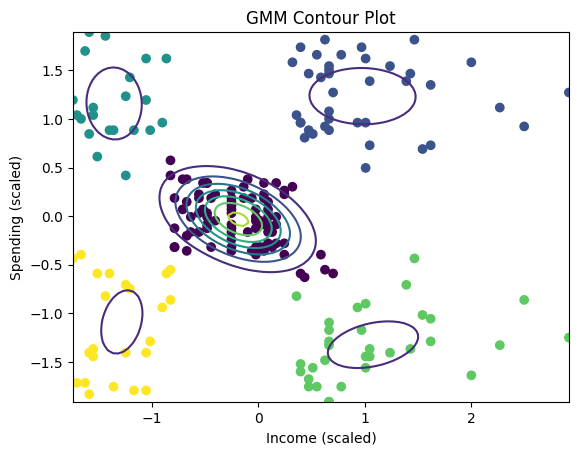

In [ ]:
plt.figure()

# Scatter points
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels)

# Create grid
x = np.linspace(X_scaled[:, 0].min(), X_scaled[:, 0].max(), 100)
y = np.linspace(X_scaled[:, 1].min(), X_scaled[:, 1].max(), 100)
X_grid, Y_grid = np.meshgrid(x, y)

grid = np.array([X_grid.ravel(), Y_grid.ravel()]).T

# Compute probability density
Z = np.exp(gmm.score_samples(grid))
Z = Z.reshape(X_grid.shape)

# Contour
plt.contour(X_grid, Y_grid, Z)

plt.title("GMM Contour Plot")
plt.xlabel("Income (scaled)")
plt.ylabel("Spending (scaled)")

plt.show()

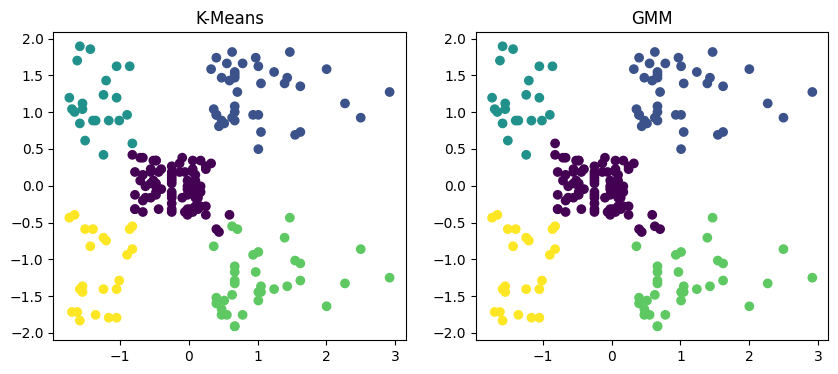

In [ ]:
plt.figure(figsize=(10, 4))

# K-Means
plt.subplot(1, 2, 1)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=clusters)
plt.title("K-Means")

# GMM
plt.subplot(1, 2, 2)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], c=gmm_labels)
plt.title("GMM")

plt.show()